In [18]:
#1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For preprocessing and clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# For visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully!
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


In [19]:
#2: Load the dataset
file_path = 'Mobile Reviews Sentiment null.csv'  

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please check the file path.")
    print("Creating sample dataset for demonstration...")
    
    # Create sample data
    np.random.seed(42)
    brands = ['Apple', 'Samsung', 'Xiaomi', 'OnePlus', 'Google', 'Sony', 'Nokia', 'Motorola']
    countries = ['USA', 'China', 'South Korea', 'India', 'Japan', 'UK', 'Germany']
    
    df = pd.DataFrame({
        'Product_ID': [f'P{1000+i}' for i in range(200)],
        'Brand': np.random.choice(brands, 200),
        'Country': np.random.choice(countries, 200),
        'Price': np.random.randint(100, 1500, 200) * 10,
        'Rating': np.round(np.random.uniform(3.0, 5.0, 200), 1),
        'Battery_mAh': np.random.choice([3000, 4000, 4500, 5000, 5500, 6000], 200),
        'RAM_GB': np.random.choice([4, 6, 8, 12, 16], 200),
        'Storage_GB': np.random.choice([64, 128, 256, 512, 1024], 200),
        'Screen_Size': np.round(np.random.uniform(5.5, 7.0, 200), 1),
        'Camera_MP': np.random.choice([12, 16, 20, 24, 48, 64, 108], 200),
        'Rating_Count': np.random.randint(100, 50000, 200)
    })
    df['Price'] = df['Price'] + (df['RAM_GB'] * 50) + (df['Storage_GB'] * 0.5)
    print(f"Sample dataset created with {len(df)} records!")

# Display basic information
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDataset Description:")
display(df.describe())

Dataset loaded successfully!
Dataset shape: (50000, 22)

First 5 rows of the dataset:


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  str    
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  str    
 4   model                 50000 non-null  str    
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  str    
 7   currency              50000 non-null  str    
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  str    
 11  country               50000 non-null  str    
 12  language              50000 non-null  str    
 13  review_date           50000 non-null  str    
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_ra

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [20]:
#3: Data Cleaning and Preprocessing

if df is not None:
    # Create a copy
    df_clean = df.copy()
    
    # Check for missing values
    print("Missing values before cleaning:")
    print(df_clean.isnull().sum())
    
    # Handle missing values
    # For numerical columns, fill with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    
    # For categorical columns, fill with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown', inplace=True)
    
    # Remove duplicate records
    df_clean.drop_duplicates(inplace=True)
    
    print(f"\nDataset shape after cleaning: {df_clean.shape}")
    print("\nMissing values after cleaning:")
    print(df_clean.isnull().sum())

Missing values before cleaning:
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

Dataset shape after cleaning: (50000, 22)

Missing values after cleaning:
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_r

Statistical Summary:


,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000



Column Names:
['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'helpful_votes', 'source']


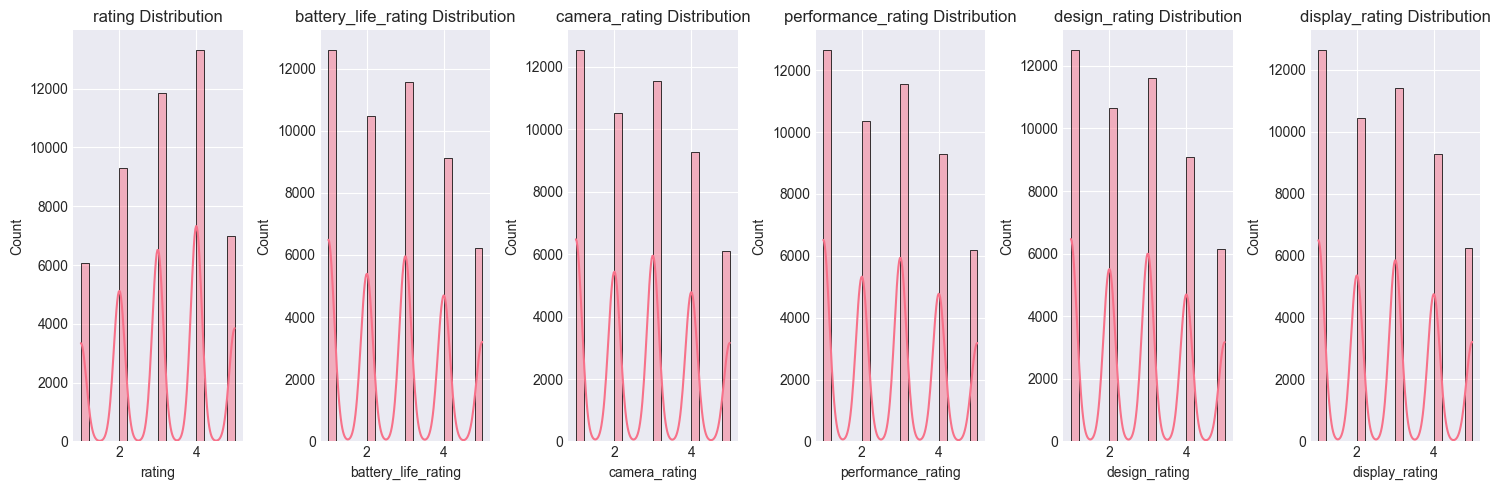

In [21]:
#4: Exploratory Data Analysis (EDA)
if df is not None:
    # Display basic statistics
    print("Statistical Summary:")
    display(df_clean.describe())
    
    # Check column names
    print("\nColumn Names:")
    print(df_clean.columns.tolist())
    
    # Price distribution
    if 'Price' in df_clean.columns or 'price' in df_clean.columns:
        price_col = 'Price' if 'Price' in df_clean.columns else 'price'
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histogram
        sns.histplot(df_clean[price_col], bins=30, kde=True, ax=axes[0])
        axes[0].set_title('Price Distribution')
        axes[0].set_xlabel('Price')
        
        # Box plot
        sns.boxplot(y=df_clean[price_col], ax=axes[1])
        axes[1].set_title('Price Box Plot')
        
        plt.tight_layout()
        plt.show()
    
    # Rating distribution
    rating_cols = [col for col in df_clean.columns if 'rating' in col.lower()]
    if rating_cols:
        fig, axes = plt.subplots(1, len(rating_cols), figsize=(15, 5))
        if len(rating_cols) == 1:
            axes = [axes]
        
        for idx, col in enumerate(rating_cols):
            sns.histplot(df_clean[col], bins=20, kde=True, ax=axes[idx])
            axes[idx].set_title(f'{col} Distribution')
            axes[idx].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()

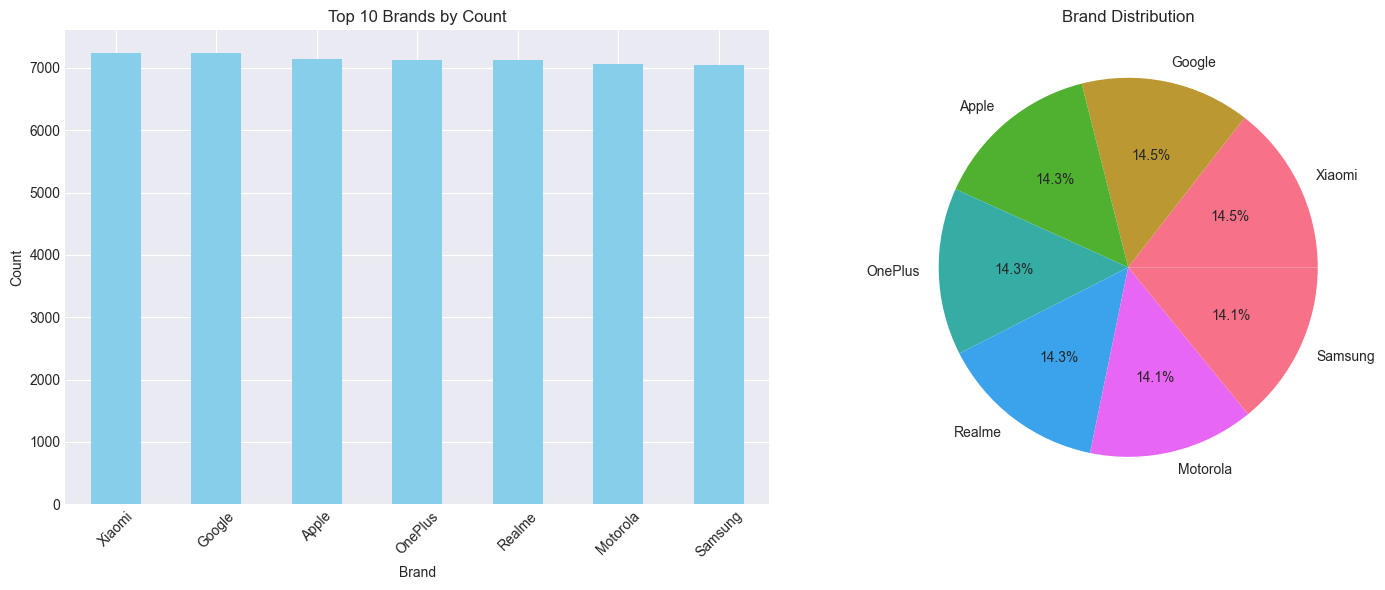

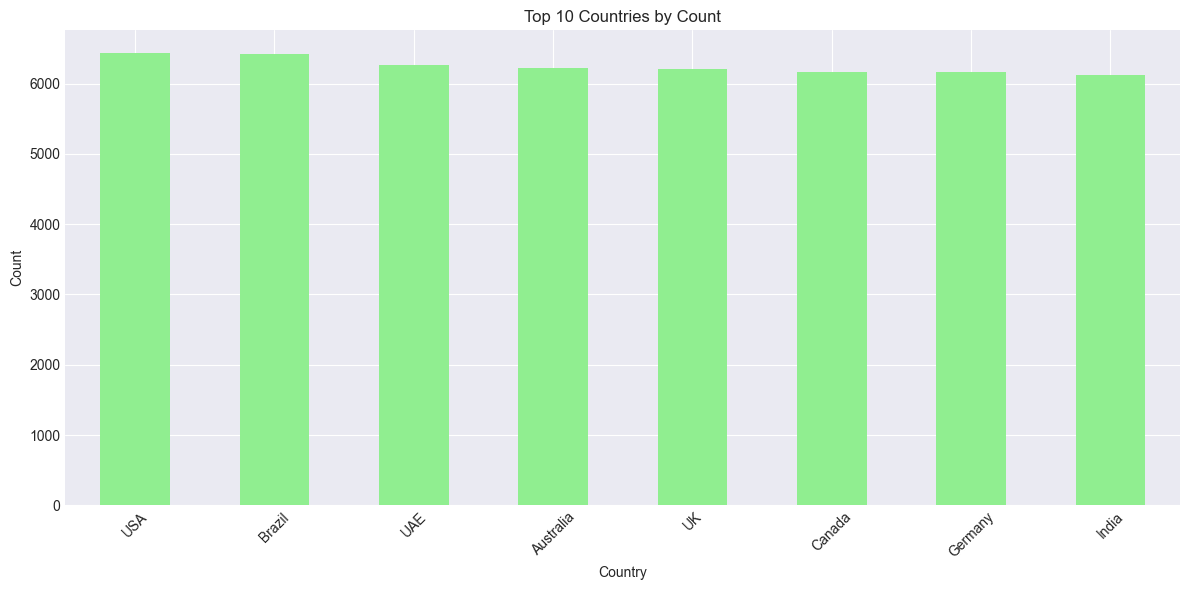

In [22]:
#5: Brand and Country Analysis

if df is not None:
    # Brand analysis
    if 'Brand' in df_clean.columns or 'brand' in df_clean.columns:
        brand_col = 'Brand' if 'Brand' in df_clean.columns else 'brand'
        brand_counts = df_clean[brand_col].value_counts().head(10)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Bar plot
        brand_counts.plot(kind='bar', ax=axes[0], color='skyblue')
        axes[0].set_title('Top 10 Brands by Count')
        axes[0].set_xlabel('Brand')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Pie chart
        brand_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
        axes[1].set_title('Brand Distribution')
        axes[1].set_ylabel('')
        
        plt.tight_layout()
        plt.show()
    
    # Country analysis
    if 'Country' in df_clean.columns or 'country' in df_clean.columns:
        country_col = 'Country' if 'Country' in df_clean.columns else 'country'
        country_counts = df_clean[country_col].value_counts().head(10)
        
        plt.figure(figsize=(12, 6))
        country_counts.plot(kind='bar', color='lightgreen')
        plt.title('Top 10 Countries by Count')
        plt.xlabel('Country')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

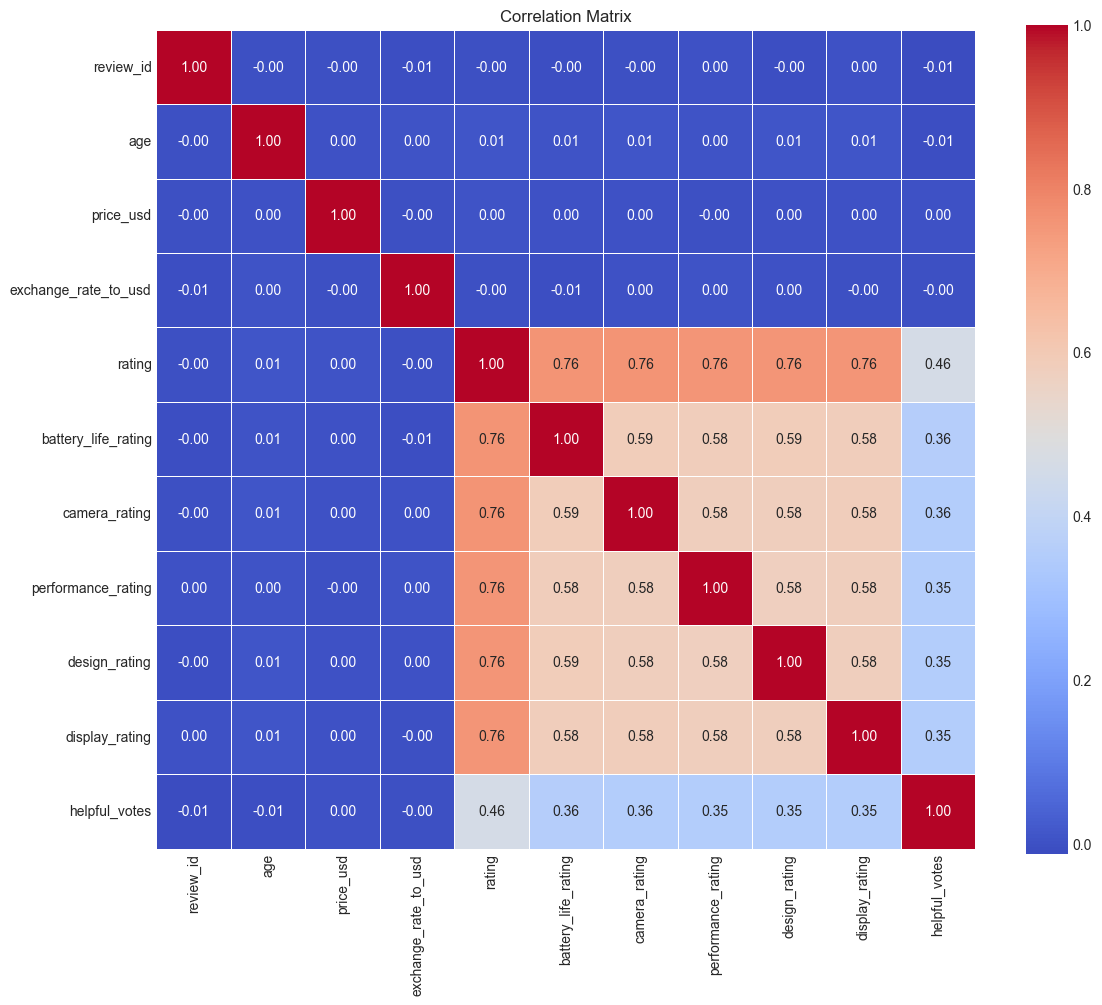

High Correlations (>0.7):
rating - battery_life_rating: 0.76
rating - camera_rating: 0.76
rating - performance_rating: 0.76
rating - design_rating: 0.76
rating - display_rating: 0.76


In [23]:
#6: Correlation Analysis

if df is not None:
    # Select numerical columns for correlation
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    numerical_df = df_clean[numerical_cols]
    
    # Calculate correlation matrix
    correlation_matrix = numerical_df.corr()
    
    # Visualize correlation matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
                linewidths=0.5, fmt='.2f', square=True)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    # Identify high correlations
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr.append((correlation_matrix.columns[i], 
                                correlation_matrix.columns[j], 
                                correlation_matrix.iloc[i, j]))
    
    if high_corr:
        print("High Correlations (>0.7):")
        for pair in high_corr:
            print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

In [24]:
#7: Feature Engineering and Selection

if df is not None:
    print("Original columns:", df_clean.columns.tolist())
    
    # Identify relevant features for clustering
    relevant_features = []
    
    # Add price if available
    if 'Price' in df_clean.columns or 'price' in df_clean.columns:
        price_col = 'Price' if 'Price' in df_clean.columns else 'price'
        relevant_features.append(price_col)
    
    # Add rating features
    rating_cols = [col for col in df_clean.columns if 'rating' in col.lower()]
    relevant_features.extend(rating_cols)
    
    # Add other numerical features
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if col not in relevant_features and 'id' not in col.lower():
            relevant_features.append(col)
    
    # Limit features to avoid too many dimensions
    relevant_features = relevant_features[:10]
    
    print(f"\nSelected features for clustering: {relevant_features}")
    
    # Create feature matrix
    X = df_clean[relevant_features].copy()
    
    # Handle categorical variables if any
    categorical_features = X.select_dtypes(include=['object']).columns
    if len(categorical_features) > 0:
        print(f"\nEncoding categorical features: {categorical_features.tolist()}")
        le = LabelEncoder()
        for col in categorical_features:
            X[col] = le.fit_transform(X[col].astype(str))
    
    print(f"\nFeature matrix shape: {X.shape}")
    display(X.head())

Original columns: ['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'helpful_votes', 'source']

Selected features for clustering: ['rating', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'age', 'price_usd', 'exchange_rate_to_usd', 'helpful_votes']

Feature matrix shape: (50000, 10)


,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,age,price_usd,exchange_rate_to_usd,helpful_votes
0,2.0,1,1,3,2,1,45,337.31,83.00,1
1,4.0,3,2,4,3,2,18,307.78,5.70,5
2,4.0,3,5,3,2,4,27,864.53,83.00,8
3,3.0,1,3,2,1,2,19,660.94,3.67,3
4,3.0,3,3,2,2,1,38,792.13,5.70,0


Feature imputation and scaling completed!
Scaled feature matrix shape: (50000, 10)


,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,age,price_usd,exchange_rate_to_usd,helpful_votes
0,-0.917131,-1.274238,-1.277067,0.207813,-0.531484,-1.273035,1.671080,-1.155806,2.671709,-1.086923
1,0.724472,0.209159,-0.533566,0.948996,0.212933,-0.533449,-1.352024,-1.253317,-0.239443,0.557327
2,0.724472,0.209159,1.696937,0.207813,-0.531484,0.945723,-0.344323,0.585136,2.671709,1.790513
3,-0.096329,-1.274238,0.209935,-0.533370,-1.275902,-0.533449,-1.240057,-0.087142,-0.315894,-0.264798
4,-0.096329,0.209159,0.209935,-0.533370,-0.531484,-1.273035,0.887312,0.346063,-0.239443,-1.497985


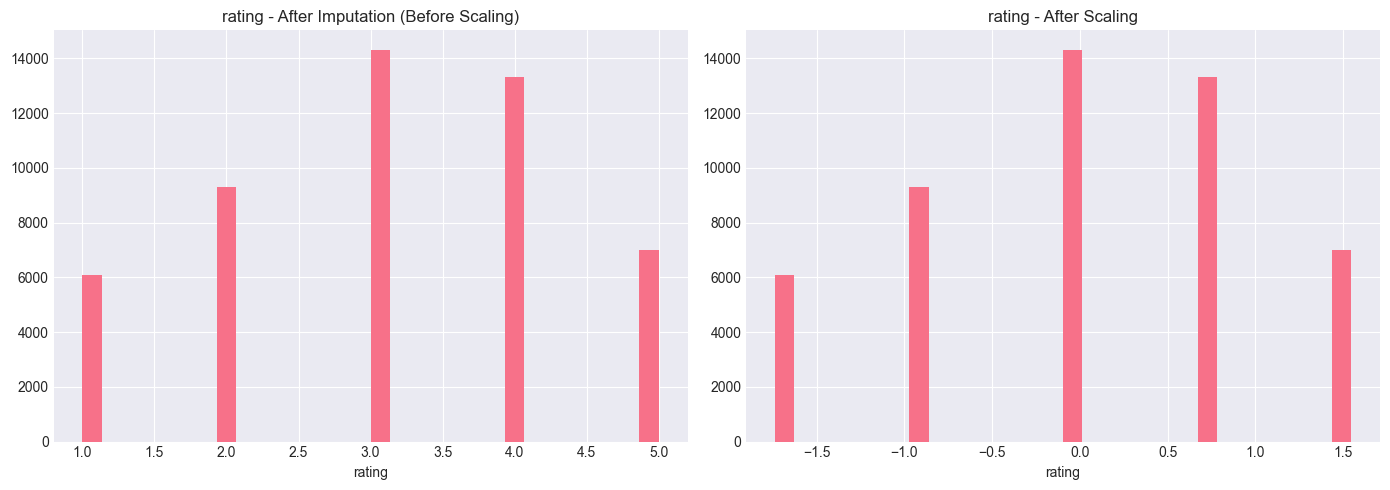

In [25]:
# 8:Feature Scaling with Imputation

if df is not None:
    # First, handle any remaining NaN values using SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # Now scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # Convert back to DataFrame for easier handling
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    
    print("Feature imputation and scaling completed!")
    print(f"Scaled feature matrix shape: {X_scaled_df.shape}")
    display(X_scaled_df.head())
    
    # Visualize scaled features
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    first_col = X.columns[0]
    pd.Series(X_imputed[:, 0]).hist(bins=30, ax=axes[0])
    axes[0].set_title(f'{first_col} - After Imputation (Before Scaling)')
    axes[0].set_xlabel(first_col)
    
    X_scaled_df[first_col].hist(bins=30, ax=axes[1])
    axes[1].set_title(f'{first_col} - After Scaling')
    axes[1].set_xlabel(first_col)
    
    plt.tight_layout()
    plt.show()

In [26]:
#9: K-Means Clustering Implementation

def perform_kmeans_clustering(X_scaled_df, n_clusters=4):
    """
    Perform K-Means clustering on the scaled data
    """
    # Convert DataFrame to numpy array if needed
    if isinstance(X_scaled_df, pd.DataFrame):
        X_array = X_scaled_df.values
    else:
        X_array = X_scaled_df
    
    # Double-check for any NaN values
    if np.any(np.isnan(X_array)):
        print("Warning: NaN values found. Applying SimpleImputer as a safeguard.")
        imputer = SimpleImputer(strategy='median')
        X_array = imputer.fit_transform(X_array)
    
    # Initialize K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    
    # Fit the model
    clusters = kmeans.fit_predict(X_array)
    
    # Calculate evaluation metrics
    try:
        silhouette = silhouette_score(X_array, clusters)
        davies_bouldin = davies_bouldin_score(X_array, clusters)
        print(f"Silhouette Score: {silhouette:.3f}")
        print(f"Davies-Bouldin Score: {davies_bouldin:.3f}")
    except Exception as e:
        print(f"Note: Could not calculate all metrics: {e}")
    
    return clusters, kmeans

if df is not None:
    # Perform clustering with 4 clusters as specified
    clusters, kmeans_model = perform_kmeans_clustering(X_scaled_df, n_clusters=4)
    
    # Add cluster labels to the original dataframe
    df_clean['Cluster'] = clusters
    
    print("\nCluster Distribution:")
    print(df_clean['Cluster'].value_counts().sort_index())
    
    print("\nCluster Centers (in scaled space):")
    print(kmeans_model.cluster_centers_)

Silhouette Score: 0.180
Davies-Bouldin Score: 1.793

Cluster Distribution:
Cluster
0    14938
1    14852
2    15563
3     4647
Name: count, dtype: int64

Cluster Centers (in scaled space):
[[ 1.01673658e+00  9.33678016e-01  9.30889062e-01  9.20961781e-01
   9.16686363e-01  9.22206068e-01  1.65901251e-02  2.05569564e-03
  -3.73270135e-01  5.84431645e-01]
 [ 6.97320444e-02 -3.83235385e-02 -4.40557736e-02 -3.90484910e-02
  -3.51558688e-02 -3.27728219e-02 -8.69352412e-03  4.11848395e-04
  -3.72349604e-01  4.06826457e-02]
 [-1.16281727e+00 -9.52430100e-01 -9.50796589e-01 -9.49490049e-01
  -9.50090622e-01 -9.51525163e-01 -1.13805732e-02  8.35210901e-04
  -8.53560730e-02 -6.65342750e-01]
 [ 4.00490250e-01  3.08763974e-01  3.30550182e-01  3.42066580e-01
   3.45373624e-01  3.24846238e-01  1.25325400e-02 -1.07040978e-02
   2.67170856e+00  2.18072031e-01]]


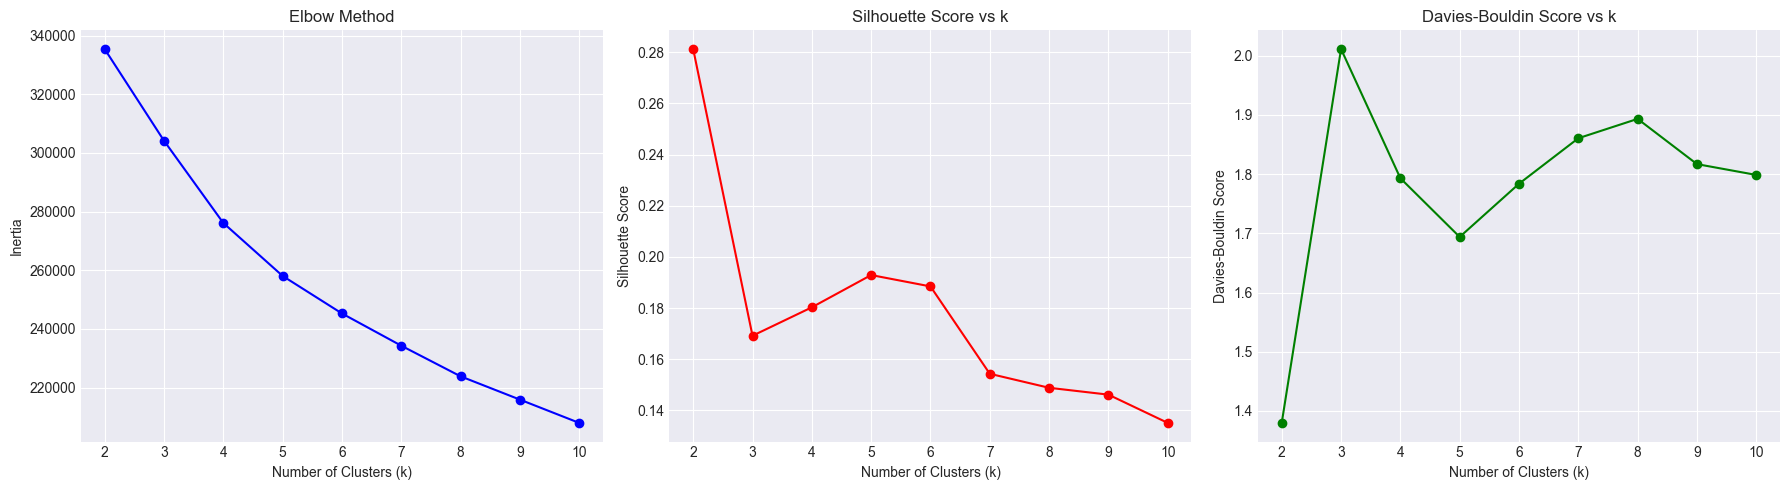

Best number of clusters based on Silhouette Score: 2


In [27]:
#10: Finding Optimal Number of Clusters

if df is not None:
    # Convert to numpy array if needed
    if isinstance(X_scaled_df, pd.DataFrame):
        X_array = X_scaled_df.values
    else:
        X_array = X_scaled_df
    
    # Elbow Method
    inertia = []
    silhouette_scores = []
    davies_bouldin_scores = []
    k_range = range(2, 11)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_array)
        inertia.append(kmeans.inertia_)
        try:
            silhouette_scores.append(silhouette_score(X_array, labels))
            davies_bouldin_scores.append(davies_bouldin_score(X_array, labels))
        except Exception as e:
            silhouette_scores.append(0)
            davies_bouldin_scores.append(0)
    
    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Elbow curve
    axes[0].plot(k_range, inertia, 'bo-')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('Elbow Method')
    axes[0].grid(True)
    
    # Silhouette scores
    if any(s > 0 for s in silhouette_scores):
        axes[1].plot(k_range, silhouette_scores, 'ro-')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Silhouette Score')
        axes[1].set_title('Silhouette Score vs k')
        axes[1].grid(True)
    
    # Davies-Bouldin scores
    if any(d > 0 for d in davies_bouldin_scores):
        axes[2].plot(k_range, davies_bouldin_scores, 'go-')
        axes[2].set_xlabel('Number of Clusters (k)')
        axes[2].set_ylabel('Davies-Bouldin Score')
        axes[2].set_title('Davies-Bouldin Score vs k')
        axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    if any(s > 0 for s in silhouette_scores):
        best_k = k_range[np.argmax(silhouette_scores)]
        print(f"Best number of clusters based on Silhouette Score: {best_k}")
    else:
        print("Could not determine optimal k from silhouette scores")

Cluster Analysis:


rating           battery_life_rating           camera_rating  \
             mean       std                mean       std          mean   
Cluster                                                                   
0        4.414990  0.518437            3.976838  0.917278      3.969675   
1        3.215453  0.522887            2.666375  0.981682      2.658363   
2        1.639184  0.571158            1.433914  0.667261      1.438990   
3        3.638770  0.923072            3.136862  1.218044      3.164622   

                  performance_rating           design_rating            \
              std               mean       std          mean       std   
Cluster                                                                  
0        0.910806           3.962177  0.920980      3.945374  0.933249   
1        0.987517           2.666981  0.993172      2.666779  0.985925   
2        0.672156           1.438669  0.678597      1.437962  0.670722   
3        1.201150           3.183559  1.217821      3.179686  1.205255   

        display_rating                  age             price_usd              \
                  mean       std       mean       std        mean         std   
Cluster                                                                         
0             3.968202  0.926642  30.223390  8.978717  690.495383  309.770160   
1             2.677081  0.994066  29.997778  8.921979  690.028676  309.835813   
2             1.434685  0.673758  29.975390  8.901522  690.151962  311.264088   
3             3.163116  1.220463  30.180762  8.903198  686.649441  310.632419   

        exchange_rate_to_usd            helpful_votes            
                        mean        std          mean       std  
Cluster                                                          
0                   2.146479   1.712983      5.065939  2.331330  
1                   2.170821   1.737838      3.743065  2.317786  
2                   9.824015  23.753172      2.026666  1.519482  
3                  83.000000   0.000000      4.174952  2.394694

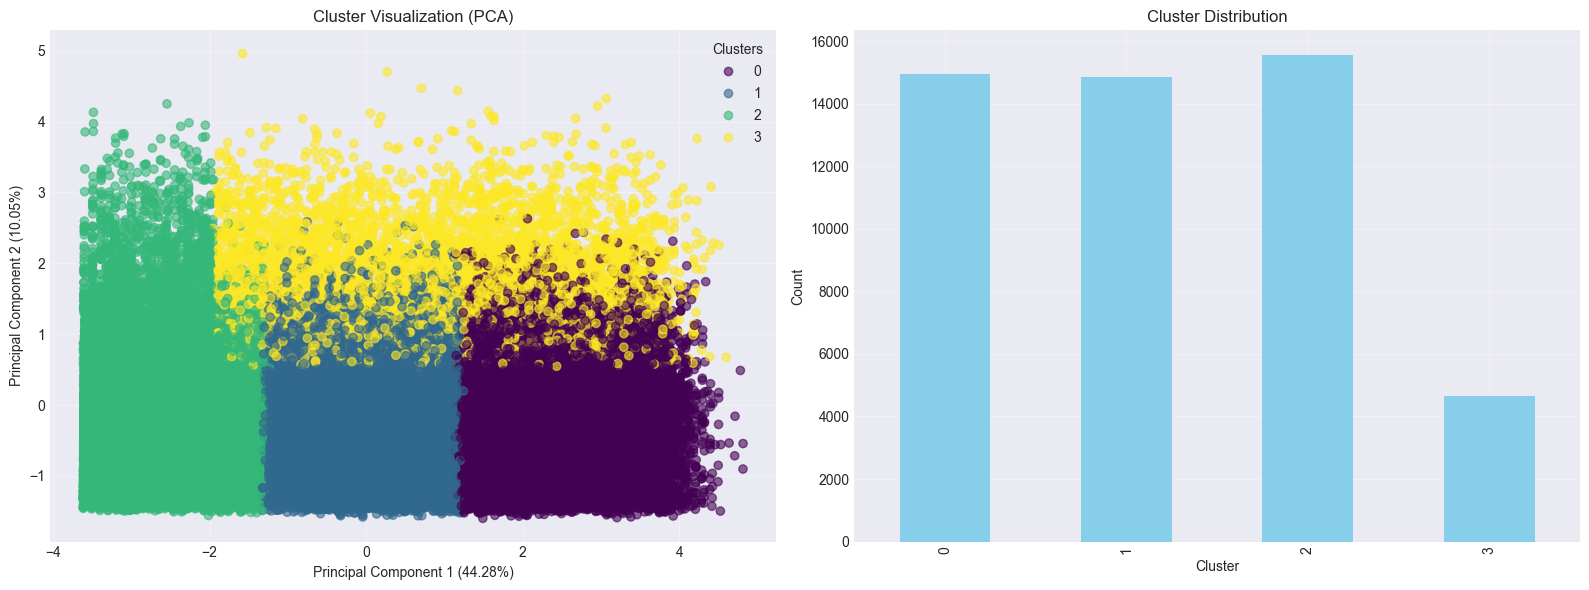

✅ Cluster visualization complete!
📊 Explained variance ratio: PC1=44.28%, PC2=10.05%


In [28]:
#11: Cluster Analysis and Visualization

if df is not None:
    # Analyze clusters
    cluster_analysis = df_clean.groupby('Cluster').agg({
        col: ['mean', 'std'] for col in X.columns
    })
    
    print("Cluster Analysis:")
    display(cluster_analysis)
    
    # 2D Visualization using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled_df.values)
    
    # Create DataFrame for visualization
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['Cluster'] = clusters
    
    # Plot clusters using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot with clusters
    scatter = axes[0].scatter(df_pca['PC1'], df_pca['PC2'], 
                              c=df_pca['Cluster'], cmap='viridis', alpha=0.6)
    axes[0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
    axes[0].set_title('Cluster Visualization (PCA)')
    axes[0].legend(*scatter.legend_elements(), title='Clusters')
    axes[0].grid(True, alpha=0.3)
    
    # Cluster distribution
    df_clean['Cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='skyblue')
    axes[1].set_title('Cluster Distribution')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Cluster visualization complete!")
    print(f"📊 Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

In [29]:
#12: Cluster Segmentation and Business Insights

if df is not None:
    print("="*60)
    print("CLUSTER SEGMENTATION AND BUSINESS INSIGHTS")
    print("="*60)
    
    # Create a summary DataFrame for each cluster
    cluster_summaries = []
    
    for cluster_id in sorted(df_clean['Cluster'].unique()):
        cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
        
        print(f"\n{'='*40}")
        print(f"CLUSTER {cluster_id}")
        print(f"Size: {len(cluster_data)} products ({len(cluster_data)/len(df_clean)*100:.1f}%)")
        print("-"*40)
        
        # Analyze features for this cluster
        for col in X.columns:
            mean_val = cluster_data[col].mean()
            overall_mean = df_clean[col].mean()
            if overall_mean != 0:
                pct_diff = (mean_val - overall_mean) / overall_mean * 100
                if abs(pct_diff) > 10:
                    status = "✓ Higher" if pct_diff > 0 else "✗ Lower"
                    print(f"   {status} than average {col}: {mean_val:.2f} (diff: {pct_diff:.1f}%)")
        
        # Identify segment type based on features
        if 'Price' in cluster_data.columns:
            avg_price = cluster_data['Price'].mean()
            price_quantiles = df_clean['Price'].quantile([0.25, 0.75])
            
            if avg_price > price_quantiles[0.75]:
                segment_type = "💰 PREMIUM SEGMENT"
            elif avg_price < price_quantiles[0.25]:
                segment_type = "💸 BUDGET SEGMENT"
            else:
                segment_type = "📊 MID-RANGE SEGMENT"
            
            print(f"\n🏷️ SEGMENT: {segment_type}")
            print(f"   Average Price: ${avg_price:.2f}")
        
        if 'Rating' in cluster_data.columns:
            print(f"   ⭐ Average Rating: {cluster_data['Rating'].mean():.2f}")
        
        # Store summary
        cluster_summaries.append({
            'Cluster': cluster_id,
            'Size': len(cluster_data),
            'Percentage': f"{len(cluster_data)/len(df_clean)*100:.1f}%",
            'Segment_Type': segment_type if 'Price' in cluster_data.columns else 'Unknown'
        })
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(cluster_summaries)
    print("\n" + "="*60)
    print("📊 CLUSTER SUMMARY TABLE")
    print("="*60)
    display(summary_df)

CLUSTER SEGMENTATION AND BUSINESS INSIGHTS

CLUSTER 0
Size: 14938 products (29.9%)
----------------------------------------
   ✓ Higher than average rating: 4.41 (diff: 41.4%)
   ✓ Higher than average battery_life_rating: 3.98 (diff: 46.3%)
   ✓ Higher than average camera_rating: 3.97 (diff: 46.1%)
   ✓ Higher than average performance_rating: 3.96 (diff: 45.7%)
   ✓ Higher than average design_rating: 3.95 (diff: 45.4%)
   ✓ Higher than average display_rating: 3.97 (diff: 45.8%)
   ✗ Lower than average exchange_rate_to_usd: 2.15 (diff: -82.2%)
   ✓ Higher than average helpful_votes: 5.07 (diff: 39.0%)

CLUSTER 1
Size: 14852 products (29.7%)
----------------------------------------
   ✗ Lower than average exchange_rate_to_usd: 2.17 (diff: -82.0%)

CLUSTER 2
Size: 15563 products (31.1%)
----------------------------------------
   ✗ Lower than average rating: 1.64 (diff: -47.5%)
   ✗ Lower than average battery_life_rating: 1.43 (diff: -47.2%)
   ✗ Lower than average camera_rating: 1.44 (di

,Cluster,Size,Percentage,Segment_Type
0,0,14938,29.9%,Unknown
1,1,14852,29.7%,Unknown
2,2,15563,31.1%,Unknown
3,3,4647,9.3%,Unknown


In [30]:
#13: Similarity-Based Recommendation System

def build_recommendation_system(df_clean, feature_columns, scaler=None):
    """
    Build a content-based recommendation system using cosine similarity
    """
    # Select features for recommendation
    X_recommend = df_clean[feature_columns].copy()
    
    # Handle categorical variables if any
    categorical_features = X_recommend.select_dtypes(include=['object']).columns
    if len(categorical_features) > 0:
        le = LabelEncoder()
        for col in categorical_features:
            X_recommend[col] = le.fit_transform(X_recommend[col].astype(str))
    
    # Handle any NaN values
    imputer = SimpleImputer(strategy='median')
    X_recommend_imputed = imputer.fit_transform(X_recommend)
    
    # Scale the features
    if scaler is None:
        scaler = StandardScaler()
        X_recommend_scaled = scaler.fit_transform(X_recommend_imputed)
    else:
        X_recommend_scaled = scaler.transform(X_recommend_imputed)
    
    # Calculate cosine similarity
    similarity_matrix = cosine_similarity(X_recommend_scaled)
    
    return similarity_matrix, scaler

if df is not None:
    # Select features for recommendation
    recommendation_features = X.columns.tolist()
    
    # Build recommendation system
    similarity_matrix, recommender_scaler = build_recommendation_system(
        df_clean, recommendation_features, scaler
    )
    
    print(f"✅ Recommendation system built!")
    print(f"   Similarity matrix shape: {similarity_matrix.shape}")

✅ Recommendation system built!
   Similarity matrix shape: (50000, 50000)


In [31]:
#14: Function to get product recommendations

def get_recommendations(product_index, similarity_matrix, df_clean, n_recommendations=5):
    """
    Get top N similar products for a given product index
    """
    # Get similarity scores for the product
    similarity_scores = list(enumerate(similarity_matrix[product_index]))
    
    # Sort products by similarity score
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    # Get top N most similar products (excluding the product itself)
    top_recommendations = similarity_scores[1:n_recommendations+1]
    
    # Get product indices and similarity scores
    product_indices = [i[0] for i in top_recommendations]
    similarity_scores_list = [i[1] for i in top_recommendations]
    
    # Return recommendations
    recommendations = df_clean.iloc[product_indices].copy()
    recommendations['Similarity_Score'] = similarity_scores_list
    
    return recommendations

# Test the recommendation system
if df is not None:
    # Get recommendations for a sample product
    sample_index = np.random.randint(0, len(df_clean))
    print(f"Product at index {sample_index}:")
    display(df_clean.iloc[sample_index][X.columns[:5]])
    
    # Get recommendations
    recommendations = get_recommendations(sample_index, similarity_matrix, df_clean, n_recommendations=5)
    print(f"\nTop 5 Similar Products:")
    display_cols = ['Similarity_Score'] + X.columns[:5].tolist()
    display(recommendations[display_cols])

Product at index 38762:


rating                 2.0
battery_life_rating      3
camera_rating            2
performance_rating       1
design_rating            2
Name: 38762, dtype: object


Top 5 Similar Products:


,Similarity_Score,rating,battery_life_rating,camera_rating,performance_rating,design_rating
10366,0.956127,2.0,3,1,1,2
36165,0.942332,1.0,3,1,1,1
13250,0.941425,2.0,3,2,1,1
42896,0.939591,2.0,2,2,1,2
9464,0.939453,2.0,2,2,1,2


In [32]:
#15: Interactive Recommendation Function

def recommend_products_by_price_range(df_clean, similarity_matrix, 
                                      min_price=None, max_price=None, 
                                      n_recommendations=5):
    """
    Get product recommendations based on price range
    """
    if 'Price' not in df_clean.columns:
        print("Price column not found!")
        return None
    
    # Filter products by price range
    if min_price is None:
        min_price = df_clean['Price'].min()
    if max_price is None:
        max_price = df_clean['Price'].max()
    
    filtered_products = df_clean[(df_clean['Price'] >= min_price) & 
                                 (df_clean['Price'] <= max_price)]
    
    if len(filtered_products) == 0:
        print("No products found in the specified price range!")
        return None
    
    # Get a random product from the filtered list
    selected_idx = filtered_products.index[np.random.randint(0, len(filtered_products))]
    
    print(f"Selected product from price range ${min_price:.0f} - ${max_price:.0f}:")
    display(df_clean.iloc[selected_idx][X.columns[:5]])
    
    # Get recommendations
    recommendations = get_recommendations(selected_idx, similarity_matrix, df_clean, n_recommendations)
    
    print(f"\nTop {n_recommendations} Recommended products:")
    return recommendations

# Test price-based recommendations
if df is not None:
    if 'Price' in df_clean.columns:
        # Get price range recommendations
        min_p = df_clean['Price'].quantile(0.25)
        max_p = df_clean['Price'].quantile(0.75)
        print(f"Testing recommendations for mid-range products (${min_p:.0f} - ${max_p:.0f})")
        print("="*60)
        recommendations_by_price = recommend_products_by_price_range(
            df_clean, similarity_matrix, min_price=min_p, max_price=max_p
        )
        if recommendations_by_price is not None:
            display_cols = ['Similarity_Score'] + X.columns[:5].tolist()
            display(recommendations_by_price[display_cols])

In [33]:
# 16:Save Results

if df is not None:
    # Save cleaned data
    df_clean.to_csv('cleaned_mobile_data.csv', index=False)
    print("✅ Cleaned data saved to 'cleaned_mobile_data.csv'")
    
    # Save cluster assignments
    cluster_data = df_clean[['Cluster'] + X.columns[:5].tolist()]
    cluster_data.to_csv('cluster_assignments.csv', index=False)
    print("✅ Cluster assignments saved to 'cluster_assignments.csv'")
    
    # Save cluster analysis
    cluster_analysis = df_clean.groupby('Cluster')[X.columns].mean()
    cluster_analysis.to_csv('cluster_analysis.csv')
    print("✅ Cluster analysis saved to 'cluster_analysis.csv'")
    
    print("\n" + "="*60)
    print("🎯 PROJECT COMPLETED SUCCESSFULLY!")
    print("="*60)

✅ Cleaned data saved to 'cleaned_mobile_data.csv'
✅ Cluster assignments saved to 'cluster_assignments.csv'
✅ Cluster analysis saved to 'cluster_analysis.csv'

🎯 PROJECT COMPLETED SUCCESSFULLY!


In [34]:
# 17:Summary of Findings

if df is not None:
    print("="*60)
    print("📋 PROJECT SUMMARY")
    print("="*60)
    
    print(f"\n📊 Dataset Overview:")
    print(f"   Total Products: {len(df_clean)}")
    print(f"   Total Features: {len(df_clean.columns)}")
    print(f"   Number of Clusters: {len(df_clean['Cluster'].unique())}")
    
    print(f"\n📈 Clustering Performance:")
    print(f"   Silhouette Score: {silhouette_score(X_scaled_df.values, clusters):.3f}")
    print(f"   Cluster Distribution:")
    for cluster_id, count in df_clean['Cluster'].value_counts().sort_index().items():
        print(f"      Cluster {cluster_id}: {count} products ({count/len(df_clean)*100:.1f}%)")
    
    print(f"\n🎯 Key Insights:")
    if 'Price' in df_clean.columns:
        print(f"   - Average Price: ${df_clean['Price'].mean():.2f}")
        print(f"   - Price Range: ${df_clean['Price'].min():.2f} - ${df_clean['Price'].max():.2f}")
    
    if 'Rating' in df_clean.columns:
        print(f"   - Average Rating: {df_clean['Rating'].mean():.2f}")
        print(f"   - Top Rating: {df_clean['Rating'].max():.2f}")
    
    print(f"\n✅ Recommendation System:")
    print(f"   - Similarity Matrix Size: {similarity_matrix.shape}")
    print(f"   - Can recommend products based on features")
    print(f"   - Supports price-based filtering")
    
    print("\n" + "="*60)
    print("🎉 THANK YOU FOR USING THE SYSTEM!")
    print("="*60)

📋 PROJECT SUMMARY

📊 Dataset Overview:
   Total Products: 50000
   Total Features: 23
   Number of Clusters: 4

📈 Clustering Performance:
   Silhouette Score: 0.180
   Cluster Distribution:
      Cluster 0: 14938 products (29.9%)
      Cluster 1: 14852 products (29.7%)
      Cluster 2: 15563 products (31.1%)
      Cluster 3: 4647 products (9.3%)

🎯 Key Insights:

✅ Recommendation System:
   - Similarity Matrix Size: (50000, 50000)
   - Can recommend products based on features
   - Supports price-based filtering

🎉 THANK YOU FOR USING THE SYSTEM!
